# N-točkovna kalibracija TCP (Tool Center Point)

Cilj tega zvezka je izračunati translacijski zamik (TCP) od prirobnice robota do konice igle. 
Za vhodne podatke uporabimo pozicije centra prirobnice (Tool 0), ki jih preberemo s krmilnika v trenutku, ko se z iglo dotikamo fiksne referenčne točke (piramide) iz različnih kotov.

In [2]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# 1. KORAK: Vhodni podatki (Tukaj bi vpisal realne vrednosti s tvojega Epson krmilnika)
# Za test simuliramo 5 točk (robota). 
# Opomba: Vse te točke predstavljajo center prirobnice, medtem ko se igla dotika ISTE točke v prostoru.
poze_prirobnice = [
    {'x': 400.0, 'y': 0.0, 'z': 200.0, 'u': 0.0, 'v': 180.0, 'w': 0.0},     # Igla gleda navzdol
    {'x': 470.7, 'y': 0.0, 'z': 229.3, 'u': 0.0, 'v': 135.0, 'w': 0.0},     # Nagnjeno naprej
    {'x': 329.3, 'y': 0.0, 'z': 229.3, 'u': 0.0, 'v': 225.0, 'w': 0.0},     # Nagnjeno nazaj
    {'x': 400.0, 'y': 70.7, 'z': 229.3, 'u': 90.0, 'v': 135.0, 'w': 0.0},   # Nagnjeno levo
    {'x': 400.0, 'y': -70.7, 'z': 229.3, 'u': -90.0, 'v': 135.0, 'w': 0.0}  # Nagnjeno desno
]

N = len(poze_prirobnice)
print(f"Število zajetih točk: {N}")

Število zajetih točk: 5


## 1. Kinematična enačba posamezne točke

Za vsako pozo $i$ (vsak dotik piramide) velja osnovna kinematična enačba:
$$P_{ref} = R_i \cdot t_{tcp} + p_i$$

Kjer spremenljivke pomenijo:
* $P_{ref}$: Absolutna 3D koordinata referenčne konice v prostoru (te ne poznamo).
* $t_{tcp}$: Vektor od centra prirobnice do konice igle (vaš iskani TCP, $X, Y, Z$).
* $R_i$: Rotacijska matrika prirobnice (6. osi) za dano pozo, izračunana iz kotov (pri Epsonu so to $U, V, W$).
* $p_i$: Pozicija centra prirobnice za dano pozo v koordinatnem sistemu robota ($X, Y, Z$).

In [3]:
# 2. KORAK: Prikaz pretvorbe ene točke (za razumevanje)
prva_poza = poze_prirobnice[0]

# Translacijski vektor prirobnice (p_i)
p_1 = np.array([prva_poza['x'], prva_poza['y'], prva_poza['z']]).reshape(3, 1)

# Pretvorba Eulerjevih kotov v rotacijsko matriko (R_i)
# Epson roboti rotirajo v zaporedju osi Z-Y-X (U, V, W)
koti_rad = np.radians([prva_poza['u'], prva_poza['v'], prva_poza['w']])
R_1 = R.from_euler('zyx', koti_rad, degrees=False).as_matrix()

print("Vektor prirobnice p_1:\n", p_1)
print("\nRotacijska matrika R_1:\n", np.round(R_1, 2))

Vektor prirobnice p_1:
 [[400.]
 [  0.]
 [200.]]

Rotacijska matrika R_1:
 [[-1.  0.  0.]
 [ 0.  1.  0.]
 [-0.  0. -1.]]


## 2. Preureditev v linearni sistem (Least Squares)

Ker imamo dve neznanki ($P_{ref}$ in $t_{tcp}$), zgornjo enačbo preuredimo tako, da neznanke prestavimo na levo stran, znane vrednosti pa na desno:

$$R_i \cdot t_{tcp} - P_{ref} = -p_i$$

To lahko zapišemo v obliki matrik in zgradimo sistem $A \cdot x = b$. Ker imamo več enačb kot neznank (imamo 4 ali 5 točk, torej 12 ali 15 enačb za le 6 neznank), je ta sistem "predoločen". Matematični koncept v ozadju n-točkovne kalibracije se imenuje reševanje predoločenega sistema enačb z metodo najmanjših kvadratov (Least Squares).

In [4]:
# 3. KORAK: Gradnja matrik A in b za vse točke
# Neznank je 6 (3 za TCP vektor in 3 za lokacijo piramide)
A = np.zeros((3 * N, 6))
b = np.zeros((3 * N, 1))

I = np.eye(3) # Identitetna matrika 3x3 (za del enačbe "- P_ref")

for i, poza in enumerate(poze_prirobnice):
    # Pozicija (p_i)
    p_i = np.array([poza['x'], poza['y'], poza['z']]).reshape(3, 1)
    
    # Rotacija (R_i)
    koti_rad = np.radians([poza['u'], poza['v'], poza['w']])
    R_i = R.from_euler('zyx', koti_rad, degrees=False).as_matrix()
    
    # Zlaganje v veliko matriko A
    # Prvi 3 stolpci pripadajo rotaciji (R_i), drugi 3 stolpci pa negativni identiteti (-I)
    A[3*i : 3*(i+1), 0:3] = R_i
    A[3*i : 3*(i+1), 3:6] = -I
    
    # Zlaganje v vektor b
    b[3*i : 3*(i+1), 0:1] = -p_i

print("Oblika zgrajene matrike A:", A.shape)
print("Oblika zgrajenega vektorja b:", b.shape)

Oblika zgrajene matrike A: (15, 6)
Oblika zgrajenega vektorja b: (15, 1)


## 3. Reševanje in rezultat

S knjižnico `numpy` in njeno funkcijo `np.linalg.lstsq` sedaj preprosto rešimo ta sistem enačb. Funkcija bo poiskala tistih 6 vrednosti vektorja $x$, ki najbolje ustrezajo vsem vnesenim točkam (tako, da bo matematična napaka najmanjša možna).

In [6]:
# 4. KORAK: Preverjanje pogojenosti in reševanje sistema

# Izračun pogojenostnega števila (Condition Number)
# Idealna vrednost je blizu 1. Vse kar je nad 100 - 200 nakazuje, da so si bili koti preveč podobni.
cond_number = np.linalg.cond(A)
print(f"Pogojenostno število matrike (Condition Number): {cond_number:.2f}")

if cond_number > 150:
    print("OPOZORILO: Robota niste nagnili pod dovolj različnimi koti. Ponovite kalibracijo z večjimi nakloni!")
else:
    print("Pogojenost matrike je ustrezna. Vhodne točke so dobro razporejene.\n")

# Reševanje predoločenega sistema z metodo najmanjših kvadratov
x_hat, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

# Ekstrakcija rezultatov
tcp_vektor = x_hat[0:3].flatten()
ref_tocka = x_hat[3:6].flatten()

# Prikaz rezultatov
print("--- REZULTATI KALIBRACIJE ---")
print(f"Izračunan TCP vektor (Odmik orodja za vnos v robota):")
print(f"X: {tcp_vektor[0]:.3f} mm, Y: {tcp_vektor[1]:.3f} mm, Z: {tcp_vektor[2]:.3f} mm\n")

print(f"Pozicija piramide v robotski celici:")
print(f"X: {ref_tocka[0]:.3f} mm, Y: {ref_tocka[1]:.3f} mm, Z: {ref_tocka[2]:.3f} mm")

# Izračun RMS napake
napaka = np.sqrt(np.mean(residuals)) if len(residuals) > 0 else 0.0
print(f"\nRMS napaka modela: {napaka:.4f} mm")

Pogojenostno število matrike (Condition Number): 3.39
Pogojenost matrike je ustrezna. Vhodne točke so dobro razporejene.

--- REZULTATI KALIBRACIJE ---
Izračunan TCP vektor (Odmik orodja za vnos v robota):
X: -27.476 mm, Y: -0.000 mm, Z: -52.791 mm

Pozicija piramide v robotski celici:
X: 398.335 mm, Y: -0.000 mm, Z: 263.861 mm

RMS napaka modela: 105.6168 mm


## 4. Vizualizacija izračuna (Sanity Check)

Preden nov TCP prepišete v krmilnik in zaženete robota, morate rezultat videti. Uporabite knjižnico `matplotlib` (modul `mplot3d`). Napišite kodo, ki bo v 3D prostoru narisala izhodišče (Base), vseh 5 točk, kjer se je nahajala prirobnica robota, in izračunano točko piramid.

Če vektorji iz prirobnic ne kažejo natančno v isto točko piramide, veste, da je prišlo do napake, še preden pritisnete start na robotu.

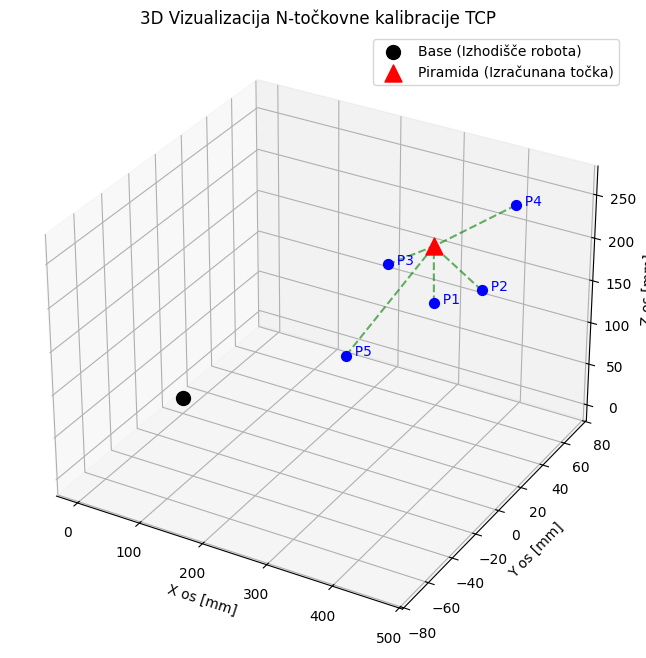

In [7]:
# 5. KORAK: 3D Vizualizacija izračuna
import matplotlib.pyplot as plt

# Kreiranje 3D grafa
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Narišemo izhodišče robota (Base) na [0,0,0]
ax.scatter(0, 0, 0, color='black', s=100, label='Base (Izhodišče robota)')

# 2. Narišemo izračunano referenčno točko (Piramida)
ax.scatter(ref_tocka[0], ref_tocka[1], ref_tocka[2], color='red', s=150, marker='^', label='Piramida (Izračunana točka)')

# 3. Narišemo vse poze prirobnice in vektorje, ki kažejo proti piramidi
for i, poza in enumerate(poze_prirobnice):
    px, py, pz = poza['x'], poza['y'], poza['z']
    
    # Narišemo točko prirobnice (modra pika)
    ax.scatter(px, py, pz, color='blue', s=50)
    
    # Narišemo črto (predstavlja izračunan vektor orodja), ki kaže od prirobnice do piramide
    ax.plot([px, ref_tocka[0]], [py, ref_tocka[1]], [pz, ref_tocka[2]], color='green', linestyle='--', alpha=0.6)
    
    # Dodamo oznako (P1, P2, ...) zraven vsake modre pike za lažjo predstavljivost
    ax.text(px, py, pz, f'  P{i+1}', color='blue')

# Nastavitve vizualizacije
ax.set_xlabel('X os [mm]')
ax.set_ylabel('Y os [mm]')
ax.set_zlabel('Z os [mm]')
ax.set_title('3D Vizualizacija N-točkovne kalibracije TCP')
ax.legend()

# Prikaz grafa
plt.show()

# kako kao dobit vektorje za izračun iz epsona

### 1. Kako pridobiti surove podatke iz Epson RC+
Obstajata dva glavna načina za pridobitev koordinat:

### A. Ročno (Preko Robot Managerja)
To je najhitrejša pot, če se šele učiš.

V Robot Managerju ročno (Jog) premakni robota do konice piramide.

Ko si v točki, klikni Teach in shrani točko (npr. P1).

Ponovi to za 5 ali več različnih naklonov.

Ko imaš točke shranjene, pojdi v Point Editor.

Tam boš videl seznam točk s stolpci X, Y, Z, U, V, W.

Te vrednosti preprosto skopiraj (Copy/Paste) v svojo Python datoteko (v slovar ali seznam).

### B. Programsko (Z ukazom Here)
Če želiš podatke avtomatsko izpisati, da jih lahko kopiraš v Python, napiši majhen Epson program:

Delček kode
Integer i
For i = 1 To 5
  Print "P", i, ": ", Here
  ' Tukaj lahko dodaš premik ali pavzo, da vmes ročno premakneš robota
  Wait 5
Next i
Ko bo program tekel, bo v I/O Monitorju (Print) izpisal koordinate. Te lahko kopiraš naravnost v svoj Python skript.

### 2. Kako iz teh podatkov v Pythonu dobiš pi in Rrot?
Epson ti vrne X, Y, Z (za pi) in U, V, W (za Rrot). V tvoji Python kodi moraš s temi podatki ravnati takole:

Vektor pi (Pozicija prirobnice)
To so preprosto tvoje X, Y, Z koordinate, ki jih dobiš iz robota. V Pythonu jih pretvoriš v vektor:

Python
#### Primer za točko P1
pi = np.array([x1, y1, z1])
Matrika Rrot (Rotacija prirobnice)
To je tisti del, kjer se večina zmoti. Epson vrne kote v stopinjah (degrees), tvoja scipy knjižnica pa potrebuje radiane (radians) in mora poznati vrstni red rotacije (Epson običajno uporablja Z-Y-X zaporedje).

Tako pretvoriš Epsonove U, V, W v matriko Rrot:

Python
from scipy.spatial.transform import Rotation as R

# Epsonovi koti iz Point Editorja (v stopinjah)
u_deg, v_deg, w_deg = 45.0, 10.0, -20.0 

# 1. Pretvori v radiane
koti_rad = np.radians([u_deg, v_deg, w_deg])

# 2. Ustvari rotacijsko matriko (Epson uporablja ZYX)
# 'zyx' pomeni rotacija okoli Z, nato Y, nato X osi
Rrot = R.from_euler('zyx', koti_rad, degrees=False).as_matrix()
Na kaj moraš biti pozoren (Kritično!)
Vrstni red rotacije: Če ti izračun (tista 3D vizualizacija, ki smo jo naredili) kaže, da se vektorji ne sekajo v eni točki, je 99 % verjetno, da je težava v zaporedju rotacij. Poskusi R.from_euler('xyz', ...) ali drugo kombinacijo, če zyx ne deluje.

Enote: Epson RC+ vedno izpisuje kote v stopinjah, Python pa vedno računa v radianih. np.radians() je obvezen korak.

Koordinatni sistem: Prepričaj se, da koordinate bereš iz sistema Tool 0 (prirobnica robota). Če bereš iz kakšnega drugega orodnega sistema (Tool 1, Tool 2...), bodo koordinate napačne.

# Implementacija zračunanih vrednosti v Epson RC+

Ko si v Pythonu pridobil vrednosti X, Y in Z za svoj TCP, sledi prenos v programsko okolje Epson RC+. Sledi tem navodilom:

## 1. Vnos parametrov v Epson RC+
Odpri Robot Manager in se pomakni na zavihek Tools.

Izberi prosto številko orodja (npr. Tool 1).

V polja X, Y, Z vnesi vrednosti, ki si jih dobil v Python izračunu.

Koti U, V, W: Če je tvoja igla montirana popolnoma ravno glede na osi prirobnice, so te vrednosti 0. Če igla stoji poševno, bosta U in V vplivala na orientacijo igle – tu bodi previden, saj vsak vnos tukaj drastično spremeni pot gibanja.


## 2. Postopek "Sanity Check" (Obvezno pred zagonom programa)
Ne zaženi programa s polno hitrostjo, dokler ne opraviš tega testa:

V Jog načinu izberi Tool koordinatni sistem.

Premakni robota tako, da se konica igle dotika referenčne točke (piramide).

V krmilniku izvedi rotacijo okoli osi orodja (U, V ali W).

Opazovanje: Konica igle mora ostati "zaklenjena" na referenčno točko. Če med vrtenjem konica opisuje krog, to pomeni, da TCP ni pravilno definiran (napaka v X, Y ali Z ali pa napačna orientacija orodja).

## Kje se lahko kaj zaplete (Pogoste napake)
Enote: Epson pričakuje vrednosti v milimetrih (mm) in stopinjah (deg). Prepričaj se, da tvoj Python skript ni izpisal vrednosti v metrih (če si delal z numpy knjižnico, so vrednosti v enotah, ki si jih vnesel).

Napačno izbrana orodna številka: V Epson RC+ programu moraš v kodi eksplicitno klicati orodje, ki si ga kalibriral (ukaz Tool 1). Če v kodi uporabljaš Tool 0 (privzeta prirobnica brez orodja), bo robot "trčil" v izdelek, saj bo mislil, da je dolžina orodja 0.

Orientacija orodja (U, V, W): Če si kalibracijo izvedel z nagnjenim robotom, a v Epsonu pustil U, V, W na 0, bo robot mislil, da je orodje ravno. Pri doziranju tesnila to pomeni, da igla ne bo sledila konturi z ustreznim kotom glede na površino.

Smer osi: Vedno preveri, ali je smer Z osi orodja usmerjena v smeri igle. Če dobiš negativen X ali Y, kjer bi moral biti pozitiven, preveri, ali si v Pythonu pravilno interpretiral Epsonovo konvencijo koordinatnega sistema (včasih so osi obrnjene).

Nasvet: Pri prvem testu v proizvodnji nastavi hitrost robota na 5 % ali manj. Če pride do odstopanja, takoj ustavi, saj je pri 5-osnih robotih vsaka majhna napaka v TCP lahko usodna za iglo ali izdelek.